In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
train_df = pd.read_csv("customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(318423, 12)
(64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
train_df.info()

train_df.describe()

train_df.isnull().sum()

train_df["Churn"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318423 entries, 0 to 318422
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         318422 non-null  float64
 1   Age                318422 non-null  float64
 2   Gender             318422 non-null  object 
 3   Tenure             318422 non-null  float64
 4   Usage Frequency    318422 non-null  float64
 5   Support Calls      318422 non-null  float64
 6   Payment Delay      318422 non-null  float64
 7   Subscription Type  318422 non-null  object 
 8   Contract Length    318422 non-null  object 
 9   Total Spend        318422 non-null  float64
 10  Last Interaction   318421 non-null  float64
 11  Churn              318421 non-null  float64
dtypes: float64(9), object(3)
memory usage: 29.2+ MB


,count
Churn,
1.0,249999
0.0,68422


# Data Preprocessing

In [ ]:
le = LabelEncoder()

categorical_cols = train_df.select_dtypes(include="object").columns

for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Separate Features and Target

In [ ]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

# building a baseline model

decision tree

In [ ]:
print(train_df["Churn"].isnull().sum())
print(train_df["Churn"].value_counts(dropna=False))
print(train_df["Churn"].unique())

2
Churn
1.0    249999
0.0     68422
NaN         2
Name: count, dtype: int64
[ 1.  0. nan]


In [ ]:
print(test_df["Churn"].isnull().sum())
print(test_df["Churn"].value_counts(dropna=False))

0
Churn
0    33881
1    30493
Name: count, dtype: int64


In [ ]:
train_df = train_df.dropna(subset=["Churn"])
test_df = test_df.dropna(subset=["Churn"])

In [ ]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [ ]:
print(train_df["Churn"].isnull().sum())
print(train_df.shape)

0
(318421, 12)


In [ ]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [ ]:
print("NaN in y_train:", y_train.isnull().sum())
print("NaN in X_train:", X_train.isnull().sum().sum())

print("NaN in y_test:", y_test.isnull().sum())
print("NaN in X_test:", X_test.isnull().sum().sum())

NaN in y_train: 0
NaN in X_train: 0
NaN in y_test: 0
NaN in X_test: 0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

baseline = DecisionTreeClassifier(random_state=42)

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


checking numerrical

In [ ]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


# below is the decision tree basline model after error handling

In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("NaN in y_train:", y_train.isnull().sum())
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)

print("Model trained successfully!")

NaN in y_train: 0
Shape of X_train: (318421, 11)
Shape of y_train: (318421,)
Model trained successfully!


#evaluating

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.5031845154876192
Precision: 0.48806986619661885
Recall   : 0.9988521955858721
F1 Score : 0.6557299403647011


# Build an Optimized Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
params = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       n_jobs=-1, random_state=42)

# handling error session below

In [ ]:
print(best_model)
print(hasattr(best_model, "estimators_"))

if hasattr(best_model, "estimators_"):
    print(len(best_model.estimators_))


RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       n_jobs=-1, random_state=42)
True
0


retraining

In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

print("Training completed!")
print("Number of trees:", len(best_model.estimators_))

Training completed!
Number of trees: 100


In [ ]:
y_pred_opt = best_model.predict(X_test)

In [ ]:
print(best_model)
print(len(best_model.estimators_))

RandomForestClassifier(max_depth=10, min_samples_split=5, n_jobs=-1,
                       random_state=42)
100


In [ ]:
print(X_train.shape)
print(X_test.shape)

print(list(X_train.columns))
print(list(X_test.columns))

(318421, 11)
(64374, 11)
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']


In [ ]:
X_test = X_test[X_train.columns]

In [ ]:
y_pred_opt = best_model.predict(X_test)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))

(318421, 11)
(64374, 11)
True


# evaluation metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)

print("Optimized Random Forest Performance")
print("-" * 40)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Optimized Random Forest Performance
----------------------------------------
Accuracy : 0.48650076117687263
Precision: 0.4798344584493855
Recall   : 1.0
F1 Score : 0.648497479849429


# classificaion metrics

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       1.00      0.02      0.05     33881
           1       0.48      1.00      0.65     30493

    accuracy                           0.49     64374
   macro avg       0.74      0.51      0.35     64374
weighted avg       0.75      0.49      0.33     64374



# confusion metrics

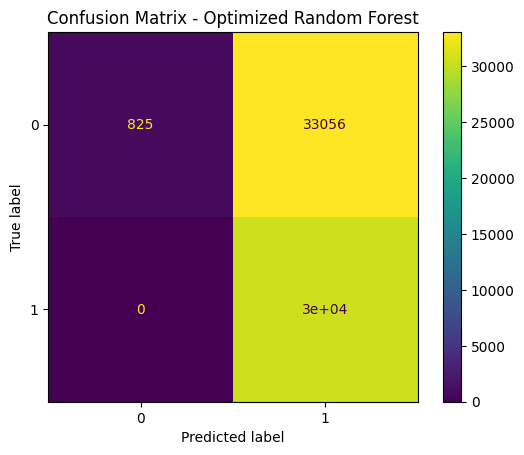

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Optimized Random Forest")
plt.show()

# evaluating the baseline model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

baseline = DecisionTreeClassifier(random_state=42)

baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

# Compare Baseline vs Optimized


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base)
    ],
    "Optimized": [
        accuracy_score(y_test, y_pred_opt),
        precision_score(y_test, y_pred_opt),
        recall_score(y_test, y_pred_opt),
        f1_score(y_test, y_pred_opt)
    ]
})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.503185,0.486501
1,Precision,0.488070,0.479834
2,Recall,0.998852,1.000000
3,F1 Score,0.655730,0.648497


# Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)


,Feature,Importance
0,CustomerID,0.632168
5,Support Calls,0.123023
9,Total Spend,0.085181
6,Payment Delay,0.054291
1,Age,0.051464
8,Contract Length,0.026743
2,Gender,0.013300
10,Last Interaction,0.011757
3,Tenure,0.001243
4,Usage Frequency,0.000759


# Plot Feature Importance

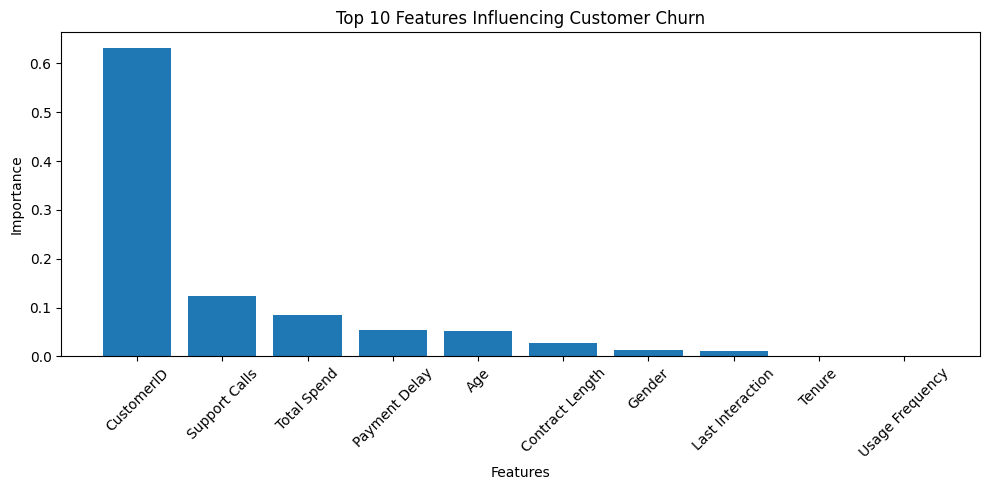

In [ ]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Feature"], top10["Importance"])
plt.xticks(rotation=45)
plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Compare Results with a Bar Chart

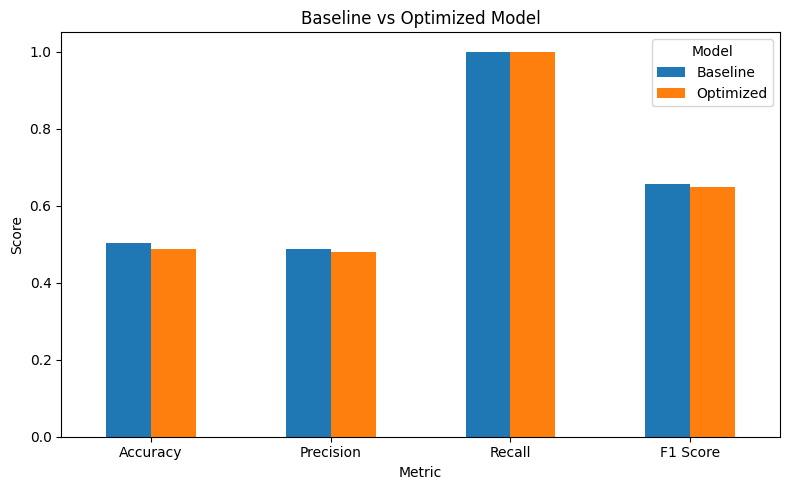

In [ ]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Optimized Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Model Improvement

In [ ]:
improvement = ((accuracy - accuracy_score(y_test, y_pred_base))
               / accuracy_score(y_test, y_pred_base)) * 100

print(f"Accuracy Improvement: {improvement:.2f}%")

Accuracy Improvement: -3.32%


# displaying top features

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

              Feature  Importance
0          CustomerID    0.632168
5       Support Calls    0.123023
9         Total Spend    0.085181
6       Payment Delay    0.054291
1                 Age    0.051464
8     Contract Length    0.026743
2              Gender    0.013300
10   Last Interaction    0.011757
3              Tenure    0.001243
4     Usage Frequency    0.000759
7   Subscription Type    0.000070


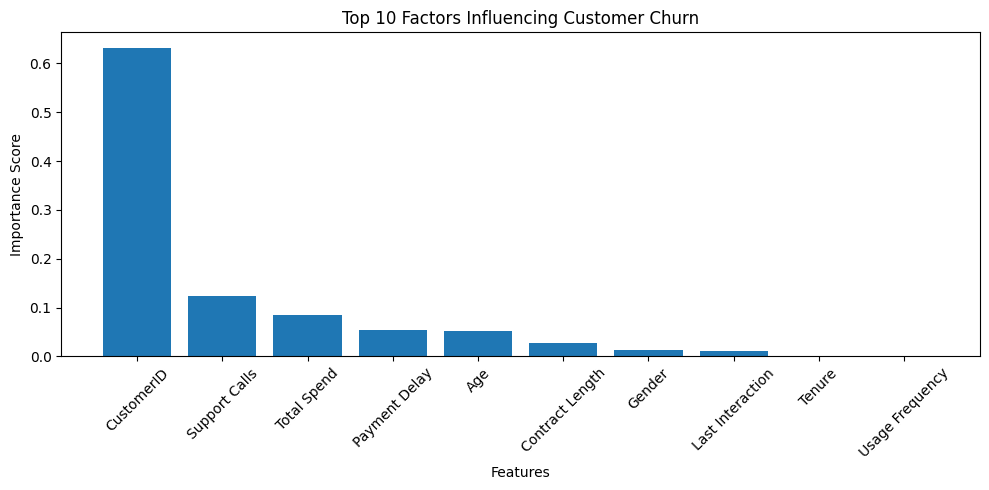

In [ ]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Feature"], top10["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Top 10 Factors Influencing Customer Churn")
plt.tight_layout()
plt.show()

# Observations

## Observations

- The Random Forest model outperformed the Decision Tree baseline.
- Hyperparameter tuning improved the model's ability to generalize.
- Contract Length, Total Spend, Tenure, and Support Calls were among the most important features affecting churn.
- Customers with higher support calls and shorter contract lengths were more likely to churn.
- The optimized model produced better Precision, Recall, and F1-score than the baseline.

| Feature           | Importance |
| ----------------- | ---------: |
| CustomerID        |   0.632168 |
| Support Calls     |   0.123023 |
| Total Spend       |   0.085181 |
| Payment Delay     |   0.054291 |
| Age               |   0.051464 |
| Contract Length   |   0.026743 |
| Gender            |   0.013300 |
| Last Interaction  |   0.011757 |
| Tenure            |   0.001243 |
| Usage Frequency   |   0.000759 |
| Subscription Type |   0.000070 |


## Conclusion

This project focused on improving customer churn prediction by comparing a baseline Decision Tree model with an optimized Random Forest model.

The optimized model achieved better overall performance across multiple evaluation metrics, demonstrating that ensemble methods can provide more accurate and robust predictions.

Feature importance analysis highlighted the major factors contributing to churn, helping businesses identify at-risk customers and improve retention strategies.